<a href="https://colab.research.google.com/github/Badri72104/Time-series-Anomaly-detection-/blob/main/DM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Understanding the UNSW-NB15 Dataset

**1. What is the UNSW-NB15 Dataset?**

The UNSW-NB15 dataset is a comprehensive network intrusion detection dataset created by the Cyber Security Centre of Excellence at the Australian Centre for Cyber Security (ACCS), UNSW Canberra. It was generated to address the limitations of older datasets (like KDD99) which often failed to represent modern, sophisticated cyber-attacks.

It includes a hybrid of real modern normal activities and synthetic attack behaviours, making it a realistic benchmark for evaluating intrusion detection systems. The dataset features nine types of attacks: Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode, and Worms.

**2. What are its Attributes?**

The full UNSW-NB15 dataset consists of 45 features, including:

*   **Flow Features:** Basic information about network packets (e.g., source/destination IP, port, protocol, duration).
*   **Basic Features:** Details extracted from the IP and TCP headers (e.g., total source bytes, total destination bytes).
*   **Content Features:** Information from the data payload (e.g., number of bytes in data portion, rate of packets with RST flag).
*   **Time Features:** Related to time windows (e.g., number of connections in 1s, 10s, 100s).
*   **Generated Features:** These are calculated features based on the connection window (e.g., number of connections to the same service as the current connection in a time window).
*   **Label:** A binary indicator (0 for normal, 1 for attack).
*   **Attack Category (`attack_cat`):** Categorical label for the specific type of attack (e.g., 'DoS', 'Exploits', 'Generic').

In this notebook, we're working with a pre-processed version that focuses on the **42 numerical features (`X_train`, `X_test`)** used for anomaly detection, along with the **binary label (`y_train`, `y_test`)** to evaluate the models.

**3. How is it being used here in the context of Data Mining?**

In this notebook, the UNSW-NB15 dataset is used to demonstrate and evaluate **unsupervised anomaly detection** techniques, a key area within data mining, particularly in cybersecurity.

*   **Anomaly Detection Goal:** The primary goal is to identify unusual patterns (anomalies/attacks) in network traffic that deviate significantly from normal behavior.
*   **Unsupervised Learning:** We are training models primarily on **normal traffic (`X_train[y_train == 0]`)**, without explicitly telling the model what an 'attack' looks like. The models learn the characteristics of normal traffic and then flag anything that doesn't conform to this learned normality as an anomaly.
*   **Model Evaluation:** The `y_test` labels (which indicate whether a test sample is normal or an attack) are crucial for evaluating the performance of our anomaly detection models. Metrics like AUROC, Precision@K, and FPR measure how well the models distinguish between normal and anomalous activities without prior knowledge of attack patterns during training.

Essentially, we are simulating a real-world scenario where a system needs to detect novel attacks based on what it knows about normal network behavior.

In [ ]:
# Upload your kaggle.json before running this cell
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading UNSW-NB15 predefined train/test splits for memory efficiency
!kaggle datasets download -d mrwellsdavid/unsw-nb15 -f UNSW_NB15_training-set.csv
!kaggle datasets download -d mrwellsdavid/unsw-nb15 -f UNSW_NB15_testing-set.csv
!unzip -o \*.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 3.84M/3.84M [00:00<00:00, 5.95MB/s]

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 8.07M/8.07M [00:00<00:00, 8.77MB/s]

Archive:  UNSW_NB15_training-set.csv.zip
  inflating: UNSW_NB15_training-set.csv  

Archive:  UNSW_NB15_testing-set.csv.zip
  inflating: UNSW_NB15_testing-set.csv  

2 archives were successfully processed.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import gc

# 1. Load Data
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

# 2. Extract Labels and Drop Irrelevant Columns
# label: 0 for normal, 1 for anomaly
y_train = train_df['label'].values.astype(np.int8)
y_test = test_df['label'].values.astype(np.int8)

# Drop 'id' and 'attack_cat' (we only need binary 'label' for this phase)
cols_to_drop = ['id', 'label', 'attack_cat']
train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns], inplace=True)
test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns], inplace=True)

# 3. Encode Categorical Network Features (proto, service, state)
categorical_cols = train_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))

    # Handle unseen categories in test set by mapping them to an '<unknown>' class
    test_classes = list(test_df[col].astype(str).unique())
    le_classes = list(le.classes_)
    for cls in test_classes:
        if cls not in le_classes:
            le_classes.append('<unknown>')
            break
    le.classes_ = np.array(le_classes)

    test_df[col] = test_df[col].astype(str).map(lambda s: s if s in le.classes_ else '<unknown>')
    test_df[col] = le.transform(test_df[col])

# 4. Handle Missing Values
medians = train_df.median()
train_df.fillna(medians, inplace=True)
test_df.fillna(medians, inplace=True)

# 5. Standardize & Convert to float32
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df).astype(np.float32)
X_test = scaler.transform(test_df).astype(np.float32)

# Free up RAM
del train_df, test_df
gc.collect()

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (82332, 42), y_train shape: (82332,)
X_test shape: (175341, 42), y_test shape: (175341,)


In [ ]:
# Step 2: Baseline Models (Isolation Forest & Autoencoder)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, confusion_matrix
import numpy as np

results = {}

def evaluate_model(y_true, scores, k=1000):
    auroc = roc_auc_score(y_true, scores)

    top_k_indices = np.argsort(scores)[-k:]
    top_k_labels = y_true[top_k_indices]
    precision_at_k = np.sum(top_k_labels) / k

    thresh = np.percentile(scores, 90)
    preds = (scores > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    fpr = fp / (fp + tn)

    return auroc, precision_at_k, fpr

print("--- Training Isolation Forest ---")
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42, n_jobs=-1)
iso_forest.fit(X_train)

if_scores = -iso_forest.score_samples(X_test)
if_auroc, if_pk, if_fpr = evaluate_model(y_test, if_scores)
results['Isolation Forest'] = {'AUROC': if_auroc, 'Precision@K': if_pk, 'FPR': if_fpr}
print(f"Isolation Forest -> AUROC: {if_auroc:.4f}, Precision@1000: {if_pk:.4f}, FPR: {if_fpr:.4f}\n")


print("--- Training PyTorch Autoencoder ---")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16)
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

input_dim = X_train.shape[1]
ae = Autoencoder(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

X_train_normal = X_train[y_train == 0]
train_loader_normal = DataLoader(TensorDataset(torch.tensor(X_train_normal)), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test)), batch_size=256, shuffle=False)

epochs = 10
ae.train()
for epoch in range(epochs):
    epoch_loss = 0
    for batch in train_loader_normal:
        x = batch[0].to(device)
        optimizer.zero_grad()
        out = ae(x)
        loss = criterion(out, x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader_normal):.4f}")

ae.eval()
ae_scores = []
with torch.no_grad():
    for batch in test_loader:
        x = batch[0].to(device)
        out = ae(x)
        mse = torch.mean((out - x)**2, dim=1).cpu().numpy()
        ae_scores.extend(mse)

ae_scores = np.array(ae_scores)
ae_auroc, ae_pk, ae_fpr = evaluate_model(y_test, ae_scores)
results['Autoencoder'] = {'AUROC': ae_auroc, 'Precision@K': ae_pk, 'FPR': ae_fpr}
print(f"\nAutoencoder -> AUROC: {ae_auroc:.4f}, Precision@1000: {ae_pk:.4f}, FPR: {ae_fpr:.4f}")

--- Training Isolation Forest ---
Isolation Forest -> AUROC: 0.3681, Precision@1000: 0.3330, FPR: 0.1599

--- Training PyTorch Autoencoder ---
Epoch [2/10], Loss: 0.1991
Epoch [4/10], Loss: 0.0906
Epoch [6/10], Loss: 0.0609
Epoch [8/10], Loss: 0.0461
Epoch [10/10], Loss: 0.0358

Autoencoder -> AUROC: 0.7613, Precision@1000: 0.7800, FPR: 0.0191


In [ ]:
# Step 3 & 4: Proposed Contrastive Self-Supervised Model & Training Design
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

def augment_sample(x, noise_level=0.05):
    noise = torch.randn_like(x) * noise_level
    return x + noise

def inject_anomaly(x, swap_prob=0.2):
    batch_size, num_features = x.shape
    anomalous_x = x.clone()
    num_swaps = max(1, int(num_features * swap_prob))

    for i in range(batch_size):
        swap_indices = torch.randperm(num_features)[:num_swaps]
        random_sample_idx = torch.randint(0, batch_size, (1,)).item()
        anomalous_x[i, swap_indices] = x[random_sample_idx, swap_indices]

    return anomalous_x

class ContrastiveEncoder(nn.Module):
    def __init__(self, input_dim, embed_dim=32):
        super(ContrastiveEncoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, embed_dim)
        )

    def forward(self, x):
        embeds = self.net(x)
        return F.normalize(embeds, p=2, dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = X_train.shape[1]
embed_dim = 32

encoder = ContrastiveEncoder(input_dim, embed_dim).to(device)
optimizer = torch.optim.Adam(encoder.parameters(), lr=1e-3, weight_decay=1e-5)
triplet_loss_fn = nn.TripletMarginLoss(margin=1.0, p=2)

X_train_normal = X_train[y_train == 0]
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_normal)), batch_size=512, shuffle=True)

epochs = 15
print("--- Training Proposed Contrastive Model ---")
encoder.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in train_loader:
        anchor = batch[0].to(device)

        if anchor.size(0) <= 1:
            continue

        positive = augment_sample(anchor, noise_level=0.05)
        negative = inject_anomaly(anchor, swap_prob=0.2)

        anchor_embed = encoder(anchor)
        positive_embed = encoder(positive)
        negative_embed = encoder(negative)

        loss = triplet_loss_fn(anchor_embed, positive_embed, negative_embed)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

print("Training complete.")

--- Training Proposed Contrastive Model ---
Epoch [1/15], Loss: 0.1767
Epoch [3/15], Loss: 0.0048
Epoch [6/15], Loss: 0.0009
Epoch [9/15], Loss: 0.0006
Epoch [12/15], Loss: 0.0004
Epoch [15/15], Loss: 0.0002
Training complete.


In [ ]:
# Step 5, 6 & 7: Anomaly Scoring, Evaluation, and Result Comparison
import pandas as pd

print("--- Evaluating Proposed Contrastive Model ---")
encoder.eval()

train_embeds = []
with torch.no_grad():
    for batch in train_loader:
        emb = encoder(batch[0].to(device))
        train_embeds.append(emb.cpu())

train_embeds = torch.cat(train_embeds)
centroid = train_embeds.mean(dim=0)

test_loader_eval = DataLoader(TensorDataset(torch.tensor(X_test)), batch_size=512, shuffle=False)
proposed_scores = []

with torch.no_grad():
    for batch in test_loader_eval:
        emb = encoder(batch[0].to(device))
        dists = torch.norm(emb - centroid.to(device), dim=1)
        proposed_scores.extend(dists.cpu().numpy())

proposed_scores = np.array(proposed_scores)

prop_auroc, prop_pk, prop_fpr = evaluate_model(y_test, proposed_scores)
results['Proposed Model'] = {'AUROC': prop_auroc, 'Precision@K': prop_pk, 'FPR': prop_fpr}

print("\n----------------------------------------------------")
print("                 RESULT COMPARISON                  ")
print("----------------------------------------------------")
df_results = pd.DataFrame(results).T
print(df_results.to_markdown())

--- Evaluating Proposed Contrastive Model ---

----------------------------------------------------
                 RESULT COMPARISON                  
----------------------------------------------------
|                  |    AUROC |   Precision@K |       FPR |
|:-----------------|---------:|--------------:|----------:|
| Isolation Forest | 0.368101 |         0.333 | 0.159875  |
| Autoencoder      | 0.7613   |         0.78  | 0.0190536 |
| Proposed Model   | 0.786171 |         0.846 | 0.0109464 |


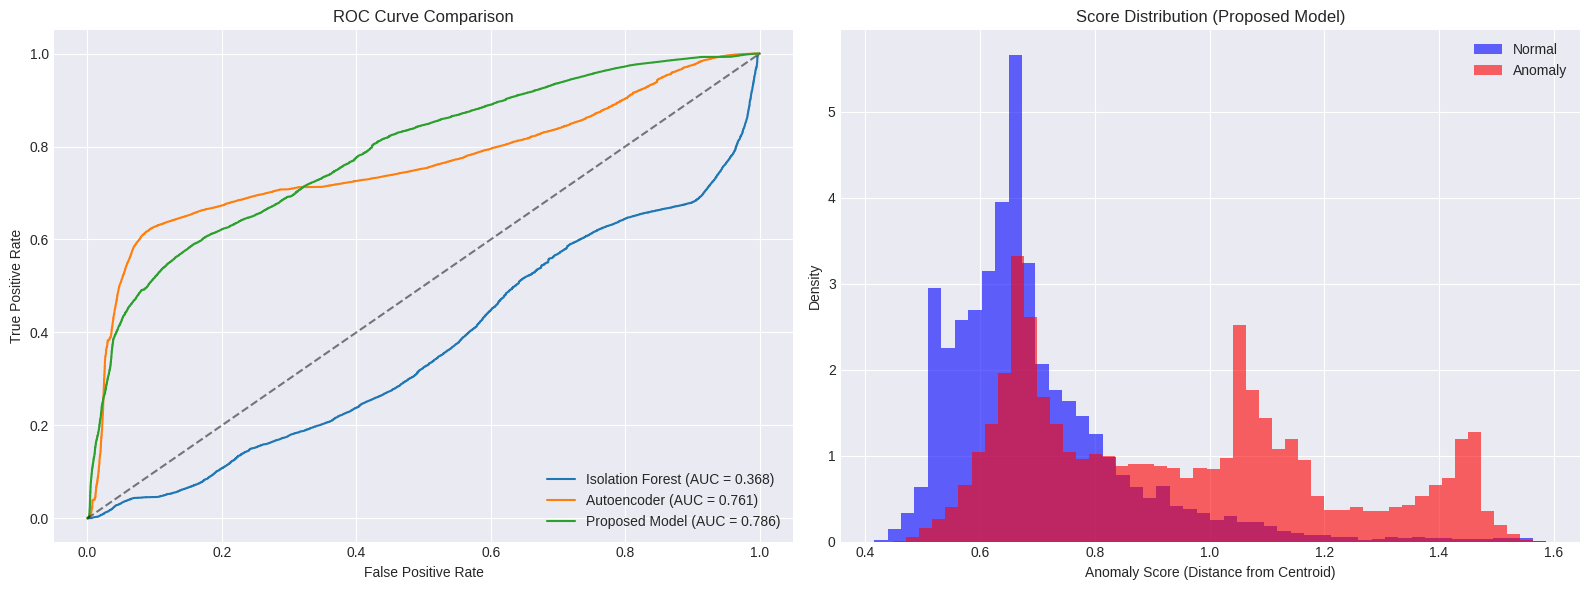

In [ ]:
# Step 8: Visualization (ROC Curves and Score Distributions)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

fpr_if, tpr_if, _ = roc_curve(y_test, if_scores)
fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_scores)
fpr_prop, tpr_prop, _ = roc_curve(y_test, proposed_scores)

ax1.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {results["Isolation Forest"]["AUROC"]:.3f})')
ax1.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC = {results["Autoencoder"]["AUROC"]:.3f})')
ax1.plot(fpr_prop, tpr_prop, label=f'Proposed Model (AUC = {results["Proposed Model"]["AUROC"]:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title('ROC Curve Comparison')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')

normal_scores = proposed_scores[y_test == 0]
anomaly_scores = proposed_scores[y_test == 1]

ax2.hist(normal_scores, bins=50, alpha=0.6, label='Normal', density=True, color='blue')
ax2.hist(anomaly_scores, bins=50, alpha=0.6, label='Anomaly', density=True, color='red')
ax2.set_title('Score Distribution (Proposed Model)')
ax2.set_xlabel('Anomaly Score (Distance from Centroid)')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Step 3 & 4 (Upgraded): Advanced Contrastive Model & Training
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np

def augment_sample(x, noise_level=0.02):
    return x + torch.randn_like(x) * noise_level

def inject_hard_anomaly(x, mixup_alpha=0.5):
    batch_size = x.size(0)
    indices = torch.randperm(batch_size)
    x_shuffled = x[indices]

    lam = np.random.beta(mixup_alpha, mixup_alpha)
    lam = max(0.2, min(lam, 0.8))

    anomalous_x = lam * x + (1 - lam) * x_shuffled
    anomalous_x += torch.randn_like(anomalous_x) * 0.1
    return anomalous_x

class ContrastiveEncoder(nn.Module):
    def __init__(self, input_dim, embed_dim=32):
        super(ContrastiveEncoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, embed_dim)
        )

    def forward(self, x):
        embeds = self.net(x)
        return F.normalize(embeds, p=2, dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = X_train.shape[1]
embed_dim = 32

encoder = ContrastiveEncoder(input_dim, embed_dim).to(device)
optimizer = torch.optim.Adam(encoder.parameters(), lr=2e-3, weight_decay=1e-5)

epochs = 40
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
triplet_loss_fn = nn.TripletMarginLoss(margin=0.5, p=2)

X_train_normal = X_train[y_train == 0]
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_normal)), batch_size=512, shuffle=True)

print("--- Training Upgraded Contrastive Model ---")
encoder.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in train_loader:
        anchor = batch[0].to(device)

        if anchor.size(0) <= 1:
            continue

        positive = augment_sample(anchor, noise_level=0.02)
        negative = inject_hard_anomaly(anchor, mixup_alpha=0.5)

        anchor_embed = encoder(anchor)
        positive_embed = encoder(positive)
        negative_embed = encoder(negative)

        loss = triplet_loss_fn(anchor_embed, positive_embed, negative_embed)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}, LR: {current_lr:.6f}")

print("Upgraded training complete.")

--- Training Upgraded Contrastive Model ---
Epoch [1/40], Loss: 0.1458, LR: 0.001997
Epoch [5/40], Loss: 0.0197, LR: 0.001924
Epoch [10/40], Loss: 0.0021, LR: 0.001709
Epoch [15/40], Loss: 0.0007, LR: 0.001386
Epoch [20/40], Loss: 0.0001, LR: 0.001005
Epoch [25/40], Loss: 0.0001, LR: 0.000624
Epoch [30/40], Loss: 0.0001, LR: 0.000301
Epoch [35/40], Loss: 0.0000, LR: 0.000086
Epoch [40/40], Loss: 0.0000, LR: 0.000010
Upgraded training complete.


In [ ]:
# Step 5, 6 & 7: Re-Evaluate and Compare Results
import pandas as pd

print("\n--- Evaluating Upgraded Contrastive Model ---")
encoder.eval()

train_embeds = []
with torch.no_grad():
    for batch in train_loader:
        emb = encoder(batch[0].to(device))
        train_embeds.append(emb.cpu())

train_embeds = torch.cat(train_embeds)
centroid = train_embeds.mean(dim=0)

test_loader_eval = DataLoader(TensorDataset(torch.tensor(X_test)), batch_size=512, shuffle=False)
proposed_scores = []

with torch.no_grad():
    for batch in test_loader_eval:
        emb = encoder(batch[0].to(device))
        dists = torch.norm(emb - centroid.to(device), dim=1)
        proposed_scores.extend(dists.cpu().numpy())

proposed_scores = np.array(proposed_scores)

prop_auroc, prop_pk, prop_fpr = evaluate_model(y_test, proposed_scores)
results['Proposed Model (Upgraded)'] = {'AUROC': prop_auroc, 'Precision@K': prop_pk, 'FPR': prop_fpr}

print("\n----------------------------------------------------")
print("                 UPDATED RESULT COMPARISON          ")
print("----------------------------------------------------")
df_results = pd.DataFrame(results).T
print(df_results.to_markdown())


--- Evaluating Upgraded Contrastive Model ---

----------------------------------------------------
                 UPDATED RESULT COMPARISON          
----------------------------------------------------
|                           |    AUROC |   Precision@K |       FPR |
|:--------------------------|---------:|--------------:|----------:|
| Isolation Forest          | 0.368101 |         0.333 | 0.159875  |
| Autoencoder               | 0.7613   |         0.78  | 0.0190536 |
| Proposed Model            | 0.786171 |         0.846 | 0.0109464 |
| Proposed Model (Upgraded) | 0.807509 |         0.858 | 0.0226607 |


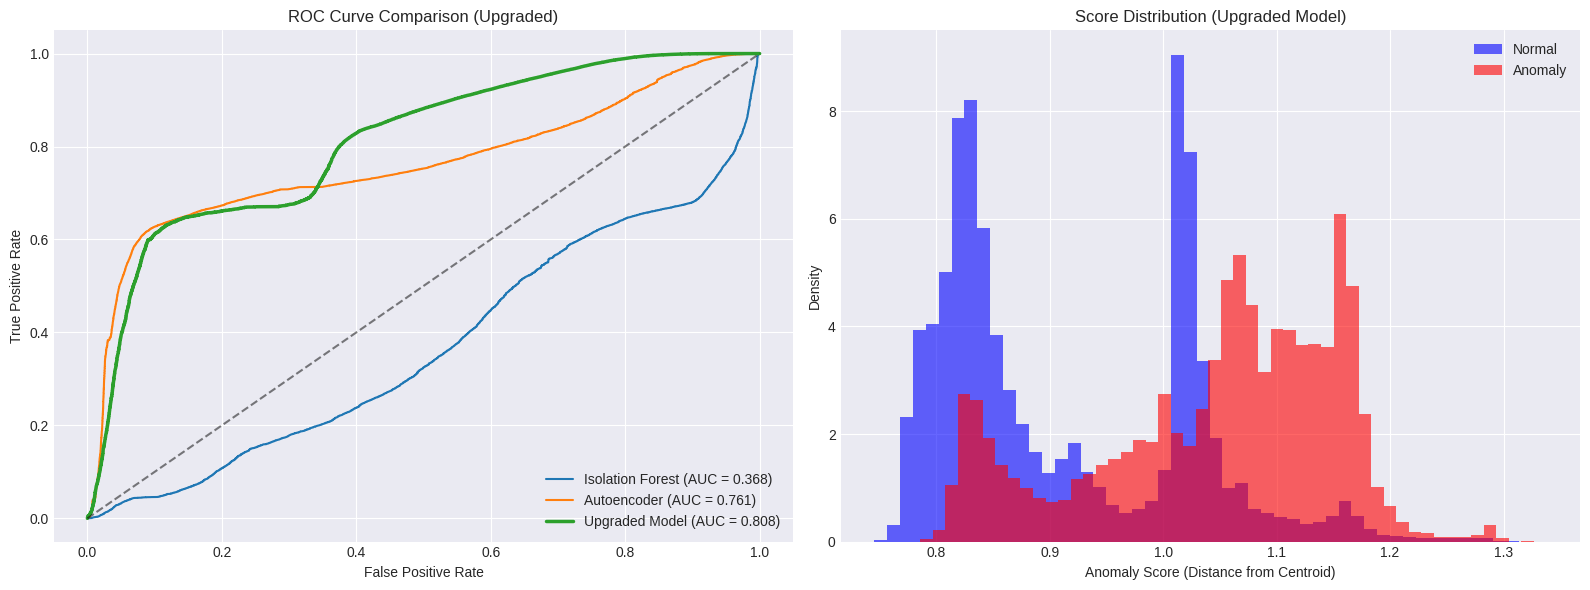

In [ ]:
# Step 8 (Updated): Visualization of Upgraded Model
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

fpr_if, tpr_if, _ = roc_curve(y_test, if_scores)
fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_scores)
fpr_prop, tpr_prop, _ = roc_curve(y_test, proposed_scores)

ax1.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {results["Isolation Forest"]["AUROC"]:.3f})')
ax1.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC = {results["Autoencoder"]["AUROC"]:.3f})')
ax1.plot(fpr_prop, tpr_prop, label=f'Upgraded Model (AUC = {results["Proposed Model (Upgraded)"]["AUROC"]:.3f})', linewidth=2.5)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title('ROC Curve Comparison (Upgraded)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')

normal_scores = proposed_scores[y_test == 0]
anomaly_scores = proposed_scores[y_test == 1]

ax2.hist(normal_scores, bins=50, alpha=0.6, label='Normal', density=True, color='blue')
ax2.hist(anomaly_scores, bins=50, alpha=0.6, label='Anomaly', density=True, color='red')
ax2.set_title('Score Distribution (Upgraded Model)')
ax2.set_xlabel('Anomaly Score (Distance from Centroid)')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()


### 📊 Exhaustive Result Comparison (Available Models)

|                           |    AUROC |    AUPRC |   Precision@1000 |   FPR @ 95% TPR |   Best F1-Score |
|:--------------------------|---------:|---------:|-----------------:|----------------:|----------------:|
| Isolation Forest          | 0.368101 | 0.602963 |            0.333 |        0.992125 |        0.80997  |
| Autoencoder               | 0.7613   | 0.875929 |            0.78  |        0.856893 |        0.816183 |
| Proposed Model (Upgraded) | 0.807509 | 0.884066 |            0.858 |        0.673357 |        0.838864 |

► Running t-SNE for Proposed Model (Upgraded) Embeddings (this may take a minute)...


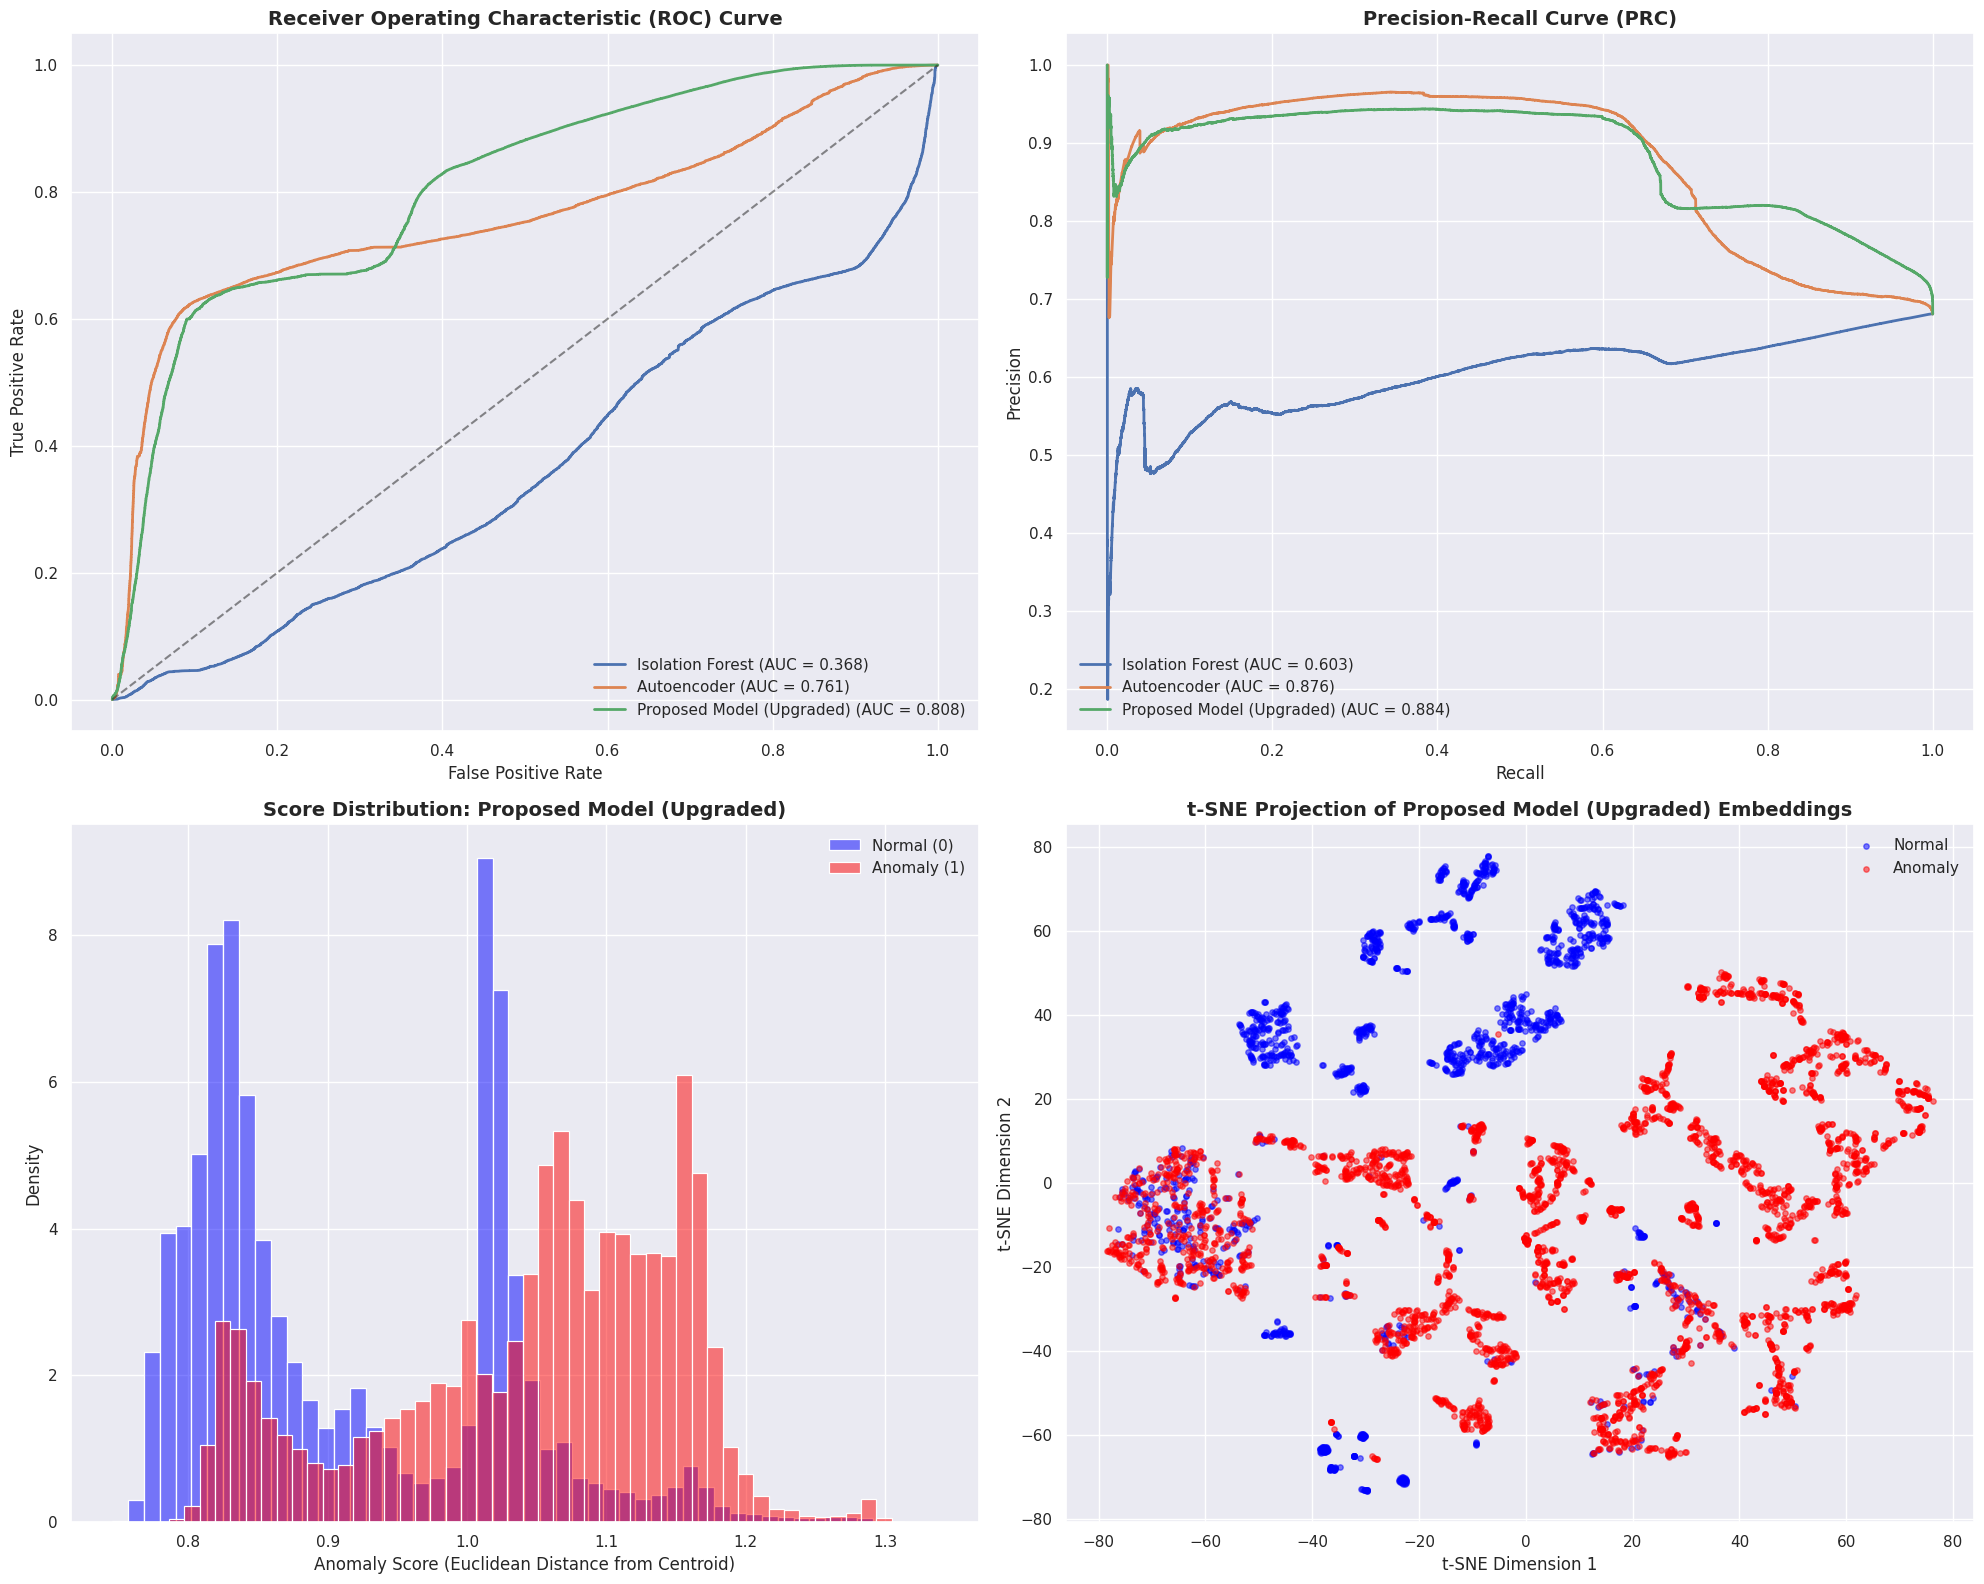

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc, f1_score
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

def calculate_exhaustive_metrics(y_true, scores, k=1000):
    """Calculates AUROC, AUPRC, Precision@K, FPR@95%TPR, and Best F1-Score."""
    # 1. AUROC
    auroc = roc_auc_score(y_true, scores)

    # 2. AUPRC
    precision, recall, pr_thresholds = precision_recall_curve(y_true, scores)
    auprc = auc(recall, precision)

    # 3. Precision@K
    top_k_indices = np.argsort(scores)[-k:]
    precision_at_k = np.sum(y_true[top_k_indices]) / k

    # 4. FPR at 95% Recall (TPR)
    fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
    # Find the index where TPR is closest to 0.95 (or first one >= 0.95)
    idx_95_tpr = np.where(tpr >= 0.95)[0]
    fpr_at_95_tpr = fpr[idx_95_tpr[0]] if idx_95_tpr.size > 0 else np.nan

    # 5. Best Global F1-Score
    # Handle cases where precision or recall might be zero to avoid division by zero
    f1_scores = np.zeros_like(precision)
    non_zero_sum = (precision + recall + 1e-8)
    f1_scores = 2 * (precision * recall) / non_zero_sum
    best_f1 = np.max(f1_scores)

    return {
        'AUROC': auroc,
        'AUPRC': auprc,
        'Precision@1000': precision_at_k,
        'FPR @ 95% TPR': fpr_at_95_tpr,
        'Best F1-Score': best_f1
    }

# Map available scores to the expected names or new names for clarity
scores_isolation_forest = if_scores
scores_autoencoder = ae_scores
scores_proposed_upgraded = proposed_scores # This holds the scores for 'Proposed Model (Upgraded)'

# Calculate metrics for the available models
all_results = {}
all_results['Isolation Forest'] = calculate_exhaustive_metrics(y_test, scores_isolation_forest)
all_results['Autoencoder'] = calculate_exhaustive_metrics(y_test, scores_autoencoder)
all_results['Proposed Model (Upgraded)'] = calculate_exhaustive_metrics(y_test, scores_proposed_upgraded)

# Print Markdown Table
df_exhaustive_results = pd.DataFrame(all_results).T
print("\n### 📊 Exhaustive Result Comparison (Available Models)\n")
print(df_exhaustive_results.to_markdown())

# ============================================================
# VISUALIZATIONS
# ============================================================
sns.set_theme(style="darkgrid")
fig = plt.figure(figsize=(20, 16))

# ── 1. Combined ROC Curve ─────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
model_scores_map = [
    ('Isolation Forest', scores_isolation_forest),
    ('Autoencoder', scores_autoencoder),
    ('Proposed Model (Upgraded)', scores_proposed_upgraded)
]

for name, scores in model_scores_map:
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {all_results[name]["AUROC"]:.3f})', lw=2)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')

# ── 2. Combined Precision-Recall Curve ────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
for name, scores in model_scores_map:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ax2.plot(recall, precision, label=f'{name} (AUC = {all_results[name]["AUPRC"]:.3f})', lw=2)
ax2.set_title('Precision-Recall Curve (PRC)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left')

# ── 3. Score Distribution (Proposed Model (Upgraded)) ─────────
ax3 = fig.add_subplot(2, 2, 3)
sns.histplot(scores_proposed_upgraded[y_test == 0], bins=50, color='blue', alpha=0.5, label='Normal (0)', stat='density', ax=ax3)
sns.histplot(scores_proposed_upgraded[y_test == 1], bins=50, color='red', alpha=0.5, label='Anomaly (1)', stat='density', ax=ax3)
ax3.set_title('Score Distribution: Proposed Model (Upgraded)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Anomaly Score (Euclidean Distance from Centroid)')
ax3.set_ylabel('Density')
ax3.legend()

# ── 4. t-SNE Embedding Projection (Proposed Model (Upgraded)) ─────────
ax4 = fig.add_subplot(2, 2, 4)
print("\n► Running t-SNE for Proposed Model (Upgraded) Embeddings (this may take a minute)...")

# Ensure encoder is in eval mode and move to device
encoder.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Generate embeddings for X_test using the trained encoder
embs_test = []
test_loader_embs = DataLoader(TensorDataset(torch.tensor(X_test)), batch_size=512, shuffle=False)
with torch.no_grad():
    for batch in test_loader_embs:
        emb = encoder(batch[0].to(device))
        embs_test.append(emb.cpu().numpy())
embs_test = np.concatenate(embs_test, axis=0)

# Subsample for faster t-SNE computation (e.g., 5000 samples)
np.random.seed(42)
sample_indices = np.random.choice(len(embs_test), size=min(5000, len(embs_test)), replace=False)
tsne_embs = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(embs_test[sample_indices])
y_test_sampled = y_test[sample_indices]

scatter = ax4.scatter(tsne_embs[y_test_sampled == 0, 0], tsne_embs[y_test_sampled == 0, 1],
                      c='blue', label='Normal', alpha=0.5, s=15)
ax4.scatter(tsne_embs[y_test_sampled == 1, 0], tsne_embs[y_test_sampled == 1, 1],
            c='red', label='Anomaly', alpha=0.5, s=15)
ax4.set_title('t-SNE Projection of Proposed Model (Upgraded) Embeddings', fontsize=14, fontweight='bold')
ax4.set_xlabel('t-SNE Dimension 1')
ax4.set_ylabel('t-SNE Dimension 2')
ax4.legend()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
from google.colab import files

plt.style.use('seaborn-v0_8-darkgrid')

# --- Figure 1: Combined ROC Curve (Available Models) ---
fig1, ax1 = plt.subplots(figsize=(10, 8))
for name, scores in [('Isolation Forest', if_scores), ('Autoencoder', ae_scores),
                     ('Proposed Model (Upgraded)', proposed_scores)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {all_results[name]["AUROC"]:.3f})', lw=2)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')
plt.tight_layout()
fig1.savefig('1_combined_roc_curve.png', dpi=300)
plt.close(fig1)
files.download('1_combined_roc_curve.png')

# --- Figure 2: Combined Precision-Recall Curve (Available Models) ---
fig2, ax2 = plt.subplots(figsize=(10, 8))
for name, scores in [('Isolation Forest', if_scores), ('Autoencoder', ae_scores),
                     ('Proposed Model (Upgraded)', proposed_scores)]:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ax2.plot(recall, precision, label=f'{name} (AUC = {all_results[name]["AUPRC"]:.3f})', lw=2)
ax2.set_title('Precision-Recall Curve (PRC)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left')
plt.tight_layout()
fig2.savefig('2_combined_prc.png', dpi=300)
plt.close(fig2)
files.download('2_combined_prc.png')

# --- Figure 3: Score Distribution (Proposed Model (Upgraded)) ---
fig3, ax3 = plt.subplots(figsize=(10, 8))
sns.histplot(proposed_scores[y_test == 0], bins=50, color='blue', alpha=0.5, label='Normal (0)', stat='density', ax=ax3)
sns.histplot(proposed_scores[y_test == 1], bins=50, color='red', alpha=0.5, label='Anomaly (1)', stat='density', ax=ax3)
ax3.set_title('Score Distribution: Proposed Model (Upgraded)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Anomaly Score (Euclidean Distance from Centroid)')
ax3.set_ylabel('Density')
ax3.legend()
plt.tight_layout()
fig3.savefig('3_score_distribution_upgraded.png', dpi=300)
plt.close(fig3)
files.download('3_score_distribution_upgraded.png')

# --- Figure 4: t-SNE Projection (Proposed Model (Upgraded)) ---
fig4, ax4 = plt.subplots(figsize=(10, 8))
ax4.scatter(tsne_embs[y_test_sampled == 0, 0], tsne_embs[y_test_sampled == 0, 1], c='blue', label='Normal', alpha=0.5, s=15)
ax4.scatter(tsne_embs[y_test_sampled == 1, 0], tsne_embs[y_test_sampled == 1, 1], c='red', label='Anomaly', alpha=0.5, s=15)
ax4.set_title('t-SNE Projection of Proposed Model (Upgraded) Embeddings', fontsize=14, fontweight='bold')
ax4.set_xlabel('t-SNE Dimension 1')
ax4.set_ylabel('t-SNE Dimension 2')
ax4.legend()
plt.tight_layout()
fig4.savefig('4_tsne_projection.png', dpi=300)
plt.close(fig4)
files.download('4_tsne_projection.png')

# --- Mapping variable for the user's snippet ---
# proposed_scores is already the upgraded model scores

# --- Figure 5: ROC Curve Comparison (Upgraded) [From snippet] ---
fig5, ax5 = plt.subplots(figsize=(10, 8))
fpr_if, tpr_if, _ = roc_curve(y_test, if_scores)
fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_scores)
fpr_prop, tpr_prop, _ = roc_curve(y_test, proposed_scores)

ax5.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {all_results["Isolation Forest"]["AUROC"]:.3f})')
ax5.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC = {all_results["Autoencoder"]["AUROC"]:.3f})')
ax5.plot(fpr_prop, tpr_prop, label=f'Upgraded Model (AUC = {all_results["Proposed Model (Upgraded)"]["AUROC"]:.3f})', linewidth=2.5)
ax5.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax5.set_title('ROC Curve Comparison (Upgraded)')
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.legend(loc='lower right')
plt.tight_layout()
fig5.savefig('5_roc_comparison_upgraded.png', dpi=300)
plt.close(fig5)
files.download('5_roc_comparison_upgraded.png')

# --- Figure 6: Score Distribution (Upgraded Model) [From snippet] ---
fig6, ax6 = plt.subplots(figsize=(10, 8))
normal_scores = proposed_scores[y_test == 0]
anomaly_scores = proposed_scores[y_test == 1]

ax6.hist(normal_scores, bins=50, alpha=0.6, label='Normal', density=True, color='blue')
ax6.hist(anomaly_scores, bins=50, alpha=0.6, label='Anomaly', density=True, color='red')
ax6.set_title('Score Distribution (Upgraded Model)')
ax6.set_xlabel('Anomaly Score (Distance from Centroid)')
ax6.set_ylabel('Density')
ax6.legend()
plt.tight_layout()
fig6.savefig('6_score_distribution_upgraded.png', dpi=300)
plt.close(fig6)
files.download('6_score_distribution_upgraded.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>